# xgb v0.2

In [1]:
!pip install xgboost

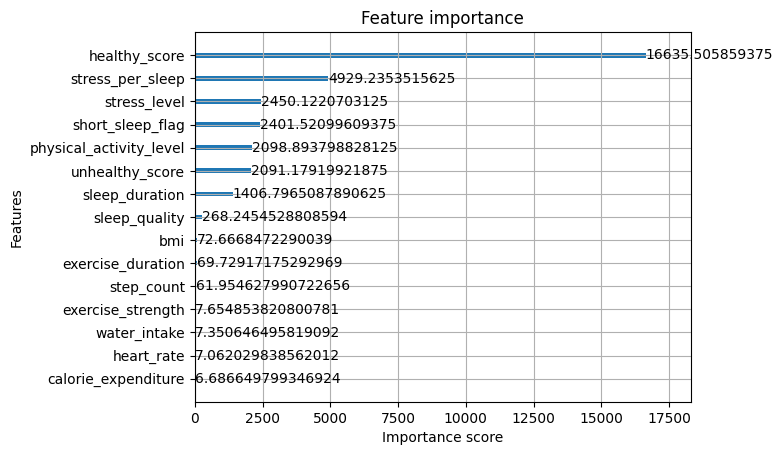


学習用Balanced Accuracy: 0.94761



提出用ファイル 'submission.csv' を作成しました☆




In [2]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

def df_Data_Cleansing(df):
    cat_cols = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().astype('category')

    #14
    df['short_sleep_flag'] = (df['sleep_duration'] < 6.0).astype(int)

    #15
    df["exercise_strength"] = df['calorie_expenditure'] / ((df['exercise_duration'] + 0.1) * df['bmi'])

    #16
    df['healthy_score'] = (
        df['sleep_duration'].between(7, 8).astype(int) +
        (df['bmi'] <= 19).astype(int) +
        (df['exercise_duration'] >= 40).astype(int) +
        (df['stress_level'] == 'low').astype(int) +
        (df['sleep_quality'] == 'good').astype(int) +
        (df['physical_activity_level'] == 'active').astype(int)
    )

    #17
    df['unhealthy_score'] = (
        df['sleep_duration'].between(5, 6).astype(int) +
        (df['bmi'] >= 27).astype(int) +
        (df['calorie_expenditure'] <= 1400).astype(int) +
        (df['step_count'] <= 5000).astype(int) +
        (df['exercise_duration'] <= 30).astype(int) +
        (df['stress_level'] == 'high').astype(int) +
        (df['sleep_quality'] == 'poor').astype(int) +
        df['physical_activity_level'].isin(['sedentary', 'moderate']).astype(int) +
        (df['smoking_alcohol'] == 'yes').astype(int)
    )
    #18
    stress_mapping = {'low': 1, 'medium': 2, 'high': 3}
    df['stress_level_num'] = df['stress_level'].map(stress_mapping).astype(float)
    df['stress_per_sleep'] = df['stress_level_num'] / df['sleep_duration']

    # 不要な特徴量をまとめて削除
    drop_cols = [
        'stress_level_num',  # 計算用の一時データ（重複）
        'diet_type',
        'gender',
        'smoking_alcohol',
    ]
    df = df.drop(columns=drop_cols, errors='ignore')

    return df

#読み込み
df = df_Data_Cleansing(pd.read_csv('data/train.csv',encoding="utf-8"))
df_test = df_Data_Cleansing(pd.read_csv('data/test.csv',encoding="utf-8"))

#特徴量(X)とターゲット(y)の分割
X = df.drop(['id', 'health_condition'], axis=1)
y = df['health_condition']

# stress_levelのラベルエンコーディング
le_stress = LabelEncoder()
X['stress_level'] = le_stress.fit_transform(X['stress_level'])
df_test['stress_level'] = le_stress.transform(df_test['stress_level'])

# 数値型の欠損値を中央値で補完（学習データの基準を使用）
NUMS = X.select_dtypes(include="float").columns.tolist() + X.select_dtypes(include="int").columns.tolist()
train_medians = X[NUMS].median()
X[NUMS] = X[NUMS].fillna(train_medians)
df_test[NUMS] = df_test[NUMS].fillna(train_medians)

#ターゲット(y)を数値に変換
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 学習データを8:2に分割
X_train, X_valid, y_train, y_valid = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# クラス不均衡を補正する重みを計算
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# モデルの学習 (enable_categorical=True を追加)
model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    enable_categorical=True,
    learning_rate=0.029880659828276236,
    max_depth=5,
    min_child_weight=9,
    subsample=0.9527064742344795,
    colsample_bytree=0.8672601416983036
)

# 学習時に重みを適用
model.fit(X_train, y_train, sample_weight=sample_weights)

xgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()

# 手元のデータで予測してスコアを計算
valid_preds = model.predict(X_valid)
score = balanced_accuracy_score(y_valid, valid_preds)

print(f"""=========================

学習用Balanced Accuracy: {score:.5f}

""")

# 全データでの学習と提出ファイルの作成
all_sample_weights = compute_sample_weight(class_weight='balanced', y=y_encoded)
model_full = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    enable_categorical=True,
    learning_rate=0.029880659828276236,
    max_depth=5,
    min_child_weight=9,
    subsample=0.9527064742344795,
    colsample_bytree=0.8672601416983036
)
model_full.fit(X, y_encoded, sample_weight=all_sample_weights)

X_test = df_test.drop(['id'], axis=1)
preds = model_full.predict(X_test)

submission_labels = le.inverse_transform(preds)

submission = pd.DataFrame({
    'id': df_test['id'],
    'health_condition': submission_labels
})
submission.to_csv('submission.csv', index=False)
X_test.head(100).to_csv("submit_x_x_x_x_x_x.csv", index=False)

print("""=========================

提出用ファイル 'submission.csv' を作成しました☆

""")